In [33]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from GarchFeature import get_garch_features
from GJRGarchFeature import get_gjrgarch_features
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_curve, auc
import optuna

In [34]:
import numpy as np
import tensorflow as tf
import random

seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

In [70]:
import warnings
import logging
import os

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=60)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 1. PRÉPARATION DES DONNÉES & LABELS

In [47]:
def prepare_stress_data_multiclass(df, lookback=60, horizon=5, q_mod=0.65, q_ext=0.85):
    dff = df.copy()
    
    # Nettoyage colonnes
    if isinstance(dff.columns, pd.MultiIndex):
        dff.columns = dff.columns.get_level_values(0)

    # --- Features de base ---
    dff["LogRet"] = np.log(dff["Close"] / dff["Close"].shift(1))
    
    # RSI (calculé proprement)
    delta = dff["LogRet"]
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = -delta.clip(upper=0).rolling(14).mean()
    dff["RSI"] = 100 - (100 / (1 + gain / (loss + 1e-9))) # +1e-9 pour éviter division par 0
    
    # --- Alignement VIX ---
    if "VIX" not in dff.columns:
        vix_data = yf.download("^VIX", start=df.index.min(), end=df.index.max(), progress=False, auto_adjust=True)
        vix_ser = vix_data['Close'].iloc[:, 0] if isinstance(vix_data.columns, pd.MultiIndex) else vix_data['Close']
        # On aligne le VIX sur les dates exactes du S&P500
        dff["VIX"] = vix_ser.reindex(dff.index).ffill()

    # --- Feature GARCH ---
    dff['GJR-GARCH_Vol'] = get_gjrgarch_features(dff)

    # --- CIBLE (Correction du Leakage) ---
    # On veut la volatilité des RENDEMENTS FUTURS uniquement : de t+1 à t+horizon
    # On calcule l'écart-type glissant, puis on le décale pour qu'à l'index 't', on ait la vol de 't+1' à 't+5'
    dff["future_vol"] = dff["LogRet"].rolling(window=horizon).std().shift(-horizon)
    
    # Calcul des seuils sur la cible non vide
    valid_vol = dff["future_vol"].dropna()
    threshold_mod = valid_vol.quantile(q_mod)
    threshold_ext = valid_vol.quantile(q_ext)
    
    # Labellisation
    dff["target_stress"] = 0
    dff.loc[dff["future_vol"] > threshold_mod, "target_stress"] = 1
    dff.loc[dff["future_vol"] > threshold_ext, "target_stress"] = 2
    
    # --- NETTOYAGE FINAL DES NaNs ---
    # Supprime :
    # 1. Les 20 premiers jours (chauffe RSI/GARCH)
    # 2. Les 5 derniers jours (car on n'a pas encore la cible future)
    dff_clean = dff.dropna(subset=["LogRet", "VIX", "GJR-GARCH_Vol", "RSI", "target_stress"])
    
    features = ["LogRet", "VIX", "GJR-GARCH_Vol", "RSI"]
    
    return dff_clean[features], dff_clean["target_stress"], (threshold_mod, threshold_ext)

# 2. CRÉATION DES SÉQUENCES (N, L, F)

In [48]:
def make_lstm_sequences(X, y, L=60):
    X_vals, y_vals = X.values, y.values
    X_seq, y_seq, dates = [], [], []
    for i in range(L, len(X)):
        X_seq.append(X_vals[i-L:i])
        y_seq.append(y_vals[i-1])
        dates.append(X.index[i-1])
    return np.array(X_seq), np.array(y_seq), pd.to_datetime(dates)

# 3. ARCHITECTURE LSTM

In [49]:
def build_multiclass_model(input_shape):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.BatchNormalization(), 
        layers.LSTM(32, return_sequences=True, dropout=0.4),
        layers.LSTM(16, dropout=0.4),
        layers.Dense(8, activation="relu"),
        layers.Dense(3, activation="softmax") 
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss="sparse_categorical_crossentropy",
        metrics=["sparse_categorical_accuracy"]
    )
    return model

# 4.EXÉCUTION & VISUALISATION

## A. Chargement et Préparation

In [50]:
data = yf.download("^GSPC", start="2010-01-01") 
X_raw, y_raw, thresholds = prepare_stress_data_multiclass(data)

[*********************100%***********************]  1 of 1 completed


Calibrage du GJR-GARCH sur le set d'entraînement...
Génération de la volatilité pour la période de test (paramètres figés)...


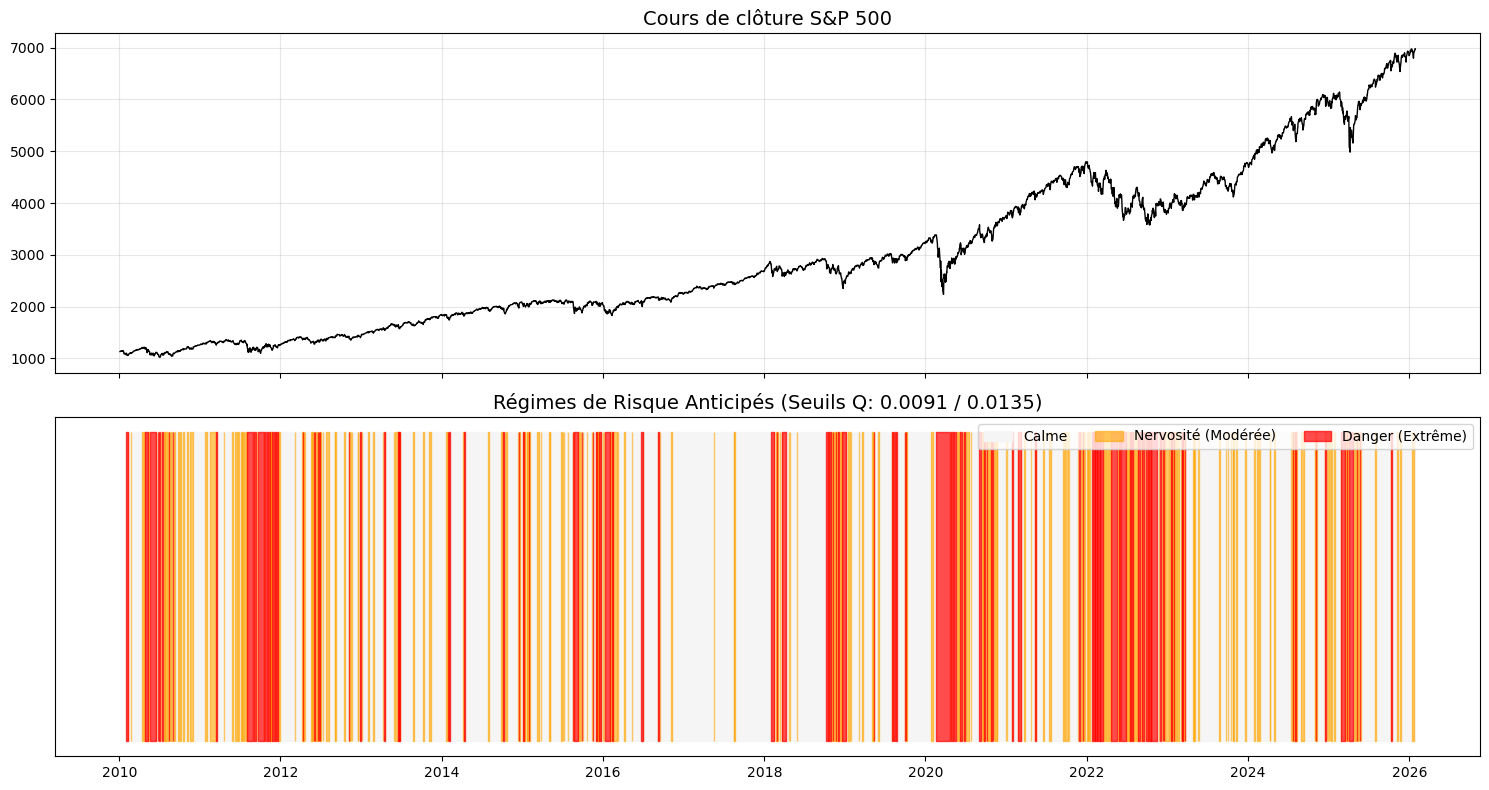

In [51]:
fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# 1. Graphique du prix
ax[0].plot(data.index, data["Close"], label="S&P 500 Price", color='black', lw=1)
ax[0].set_title("Cours de clôture S&P 500", fontsize=14)
ax[0].grid(True, alpha=0.3)

# 2. Graphique des zones de régimes
# On utilise fill_between pour colorer les zones selon l'intensité
ax[1].fill_between(y_raw.index, 0, 1, where=(y_raw == 0), color='whitesmoke', label="Calme")
ax[1].fill_between(y_raw.index, 0, 1, where=(y_raw == 1), color='orange', alpha=0.6, label="Nervosité (Modérée)")
ax[1].fill_between(y_raw.index, 0, 1, where=(y_raw == 2), color='red', alpha=0.7, label="Danger (Extrême)")

# Mise en forme du graphique des labels
ax[1].set_yticks([]) # Cache les chiffres 0, 1, 2 sur l'axe Y pour plus de clarté
ax[1].set_title(f"Régimes de Risque Anticipés (Seuils Q: {thresholds[0]:.4f} / {thresholds[1]:.4f})", fontsize=14)
ax[1].legend(loc='upper right', ncol=3)

plt.tight_layout()
plt.show()

## B. Split et Normalisation

In [52]:
split = int(len(X_raw) * 0.8)
X_train_df, X_test_df = X_raw.iloc[:split], X_raw.iloc[split:]
y_train_df, y_test_df = y_raw.iloc[:split], y_raw.iloc[split:]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_df), index=X_train_df.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_df), index=X_test_df.index)

## C. Séquençage

In [53]:
L = 60
X_train, y_train, _ = make_lstm_sequences(X_train_scaled, y_train_df, L=L)
X_test, y_test, test_dates = make_lstm_sequences(X_test_scaled, y_test_df, L=L)

## D. Entraînement avec Class Weights

In [54]:
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
dict_weights = {i: weights[i] for i in range(len(weights))}

model = build_multiclass_model((X_train.shape[1], X_train.shape[2]))
# On réduit la patience pour couper l'entraînement dès que la val_loss diverge
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

In [55]:
print(f"Entraînement du modèle régularisé")
history = model.fit(
    X_train, y_train, 
    validation_split=0.15, # On augmente un peu la validation pour plus de fiabilité
    epochs=100, # On peut mettre plus d'époques, EarlyStopping s'occupe du reste
    batch_size=64, # Batch plus large pour lisser le gradient
    callbacks=[early_stop],
    class_weight=dict_weights,
    verbose=1
)

Entraînement du modèle régularisé
Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - loss: 1.0263 - sparse_categorical_accuracy: 0.5665 - val_loss: 1.0252 - val_sparse_categorical_accuracy: 0.4536
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.9569 - sparse_categorical_accuracy: 0.6478 - val_loss: 0.9660 - val_sparse_categorical_accuracy: 0.4494
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.9121 - sparse_categorical_accuracy: 0.6478 - val_loss: 0.9435 - val_sparse_categorical_accuracy: 0.4599
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.8781 - sparse_categorical_accuracy: 0.6705 - val_loss: 0.9094 - val_sparse_categorical_accuracy: 0.6160
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.8383 - sparse_categorical_accuracy: 0.6877 - val_loss: 0.8740 - val_sparse_categorical_accuracy: 0.6245
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.8114 - sparse_categorical_accuracy: 0.6966 - val_loss: 0.8533 - val_sparse

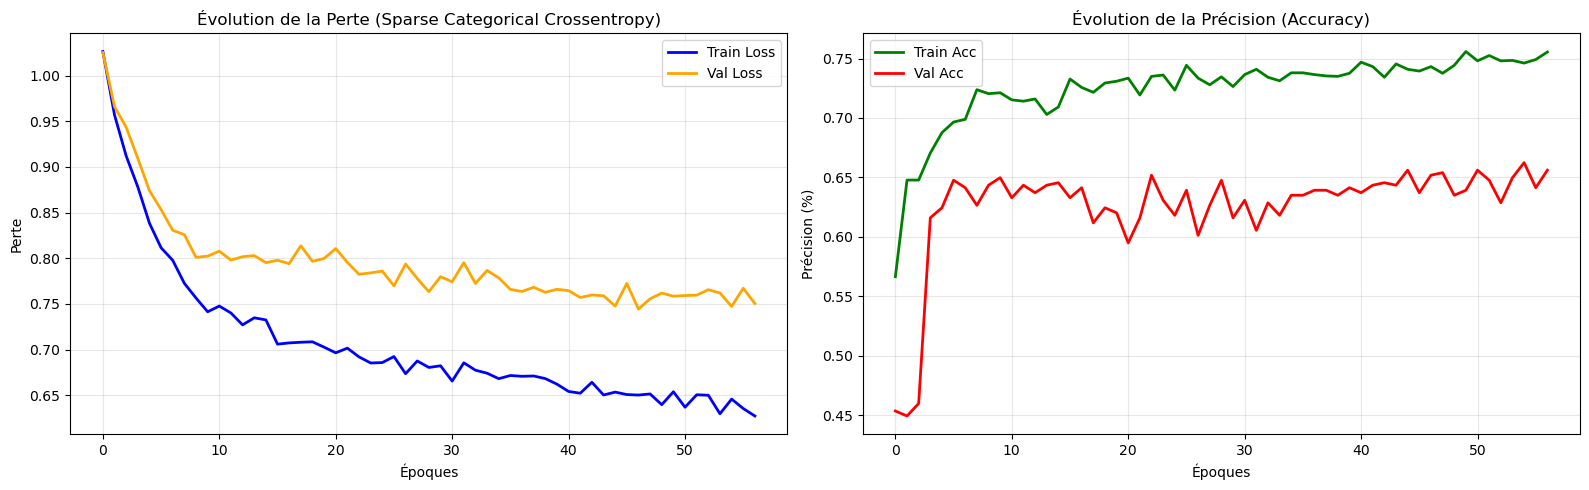

In [56]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 1. Graphique de la Perte (Loss)
ax1.plot(history.history['loss'], label='Train Loss', color='blue', lw=2)
ax1.plot(history.history['val_loss'], label='Val Loss', color='orange', lw=2)
ax1.set_title("Évolution de la Perte (Sparse Categorical Crossentropy)")
ax1.set_xlabel("Époques")
ax1.set_ylabel("Perte")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Graphique de la Précision (Accuracy)
# On utilise 'sparse_categorical_accuracy' car c'est la métrique par défaut pour ce type de loss
acc_name = 'sparse_categorical_accuracy'
ax2.plot(history.history[acc_name], label='Train Acc', color='green', lw=2)
ax2.plot(history.history[f'val_{acc_name}'], label='Val Acc', color='red', lw=2)
ax2.set_title("Évolution de la Précision (Accuracy)")
ax2.set_xlabel("Époques")
ax2.set_ylabel("Précision (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## E. Prédictions et Diagnostics (filtre de confiance)

In [57]:
# --- ÉTAPE A : Définition de la fonction de seuillage ---
def predict_with_threshold(probas, danger_level=0.5, nervous_level=0.4):
    preds = []
    for p in probas:
        # p[0]=Calme, p[1]=Nervosité, p[2]=Danger
        if p[2] >= danger_level:
            preds.append(2)  # Priorité Protection
        elif p[1] >= nervous_level:
            preds.append(1)  # Prudence
        else:
            preds.append(0)  # Confiance
    return np.array(preds)

y_proba = model.predict(X_test)
y_pred = predict_with_threshold(y_proba, danger_level=0.5, nervous_level=0.4)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


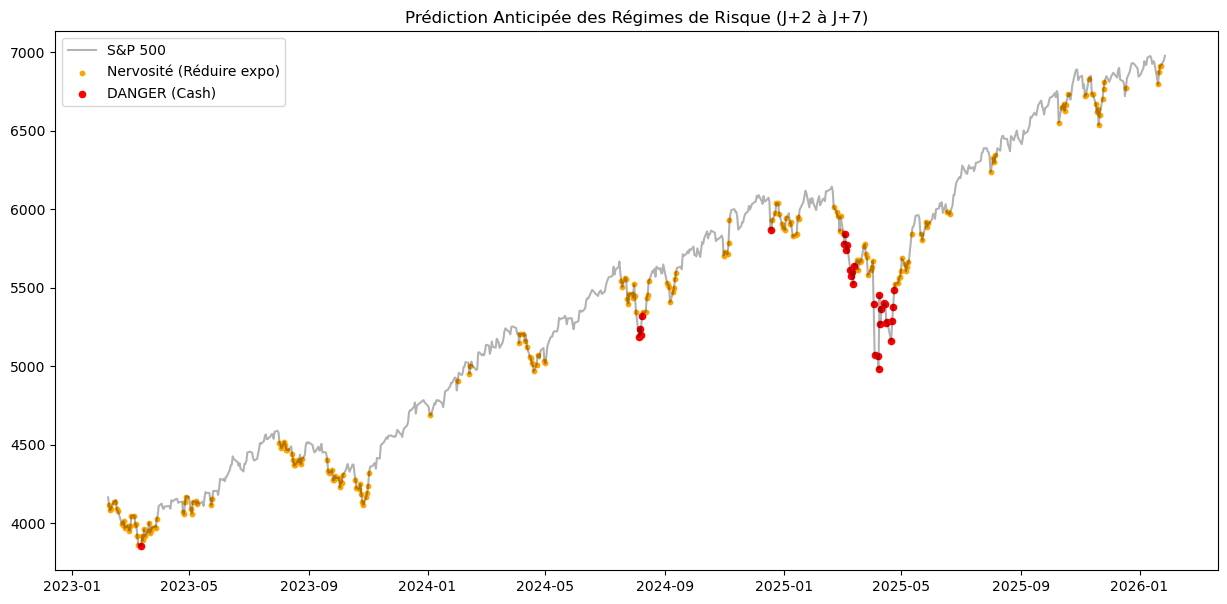

In [58]:
test_prices = data.loc[test_dates, "Close"]
plt.figure(figsize=(15, 7))
plt.plot(test_dates, test_prices, label="S&P 500", color='black', alpha=0.3)

# Affichage des 3 régimes
plt.scatter(test_dates[y_pred == 1], test_prices[y_pred == 1], color='orange', s=10, label="Nervosité (Réduire expo)")
plt.scatter(test_dates[y_pred == 2], test_prices[y_pred == 2], color='red', s=20, label="DANGER (Cash)")

plt.title("Prédiction Anticipée des Régimes de Risque (J+2 à J+7)")
plt.legend()
plt.show()

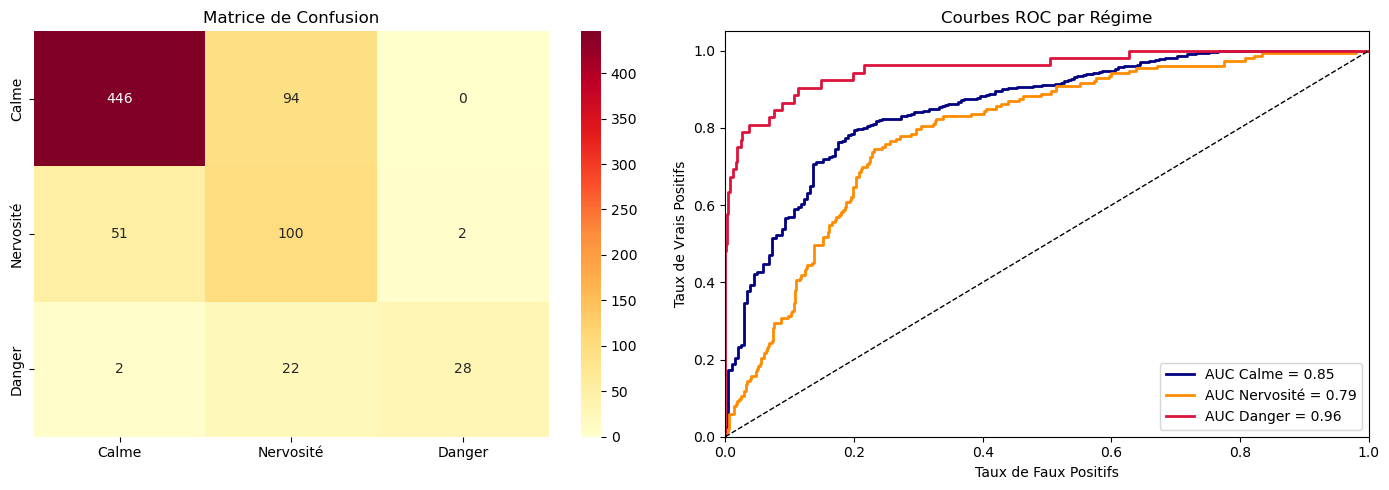

In [59]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=['Calme', 'Nervosité', 'Danger'], 
            yticklabels=['Calme', 'Nervosité', 'Danger'], ax=ax1)
ax1.set_title("Matrice de Confusion")

# Courbe ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3
colors = ['navy', 'darkorange', 'crimson']
labels = ['Calme', 'Nervosité', 'Danger']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'AUC {labels[i]} = {roc_auc:.2f}')

ax2.plot([0, 1], [0, 1], 'k--', lw=1)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Taux de Faux Positifs')
ax2.set_ylabel('Taux de Vrais Positifs')
ax2.set_title('Courbes ROC par Régime')
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

# 5. Cellule de Backtest : ROBO-ADVISOR VS BUY & HOLD

## A. Configuration et téléchargement des actfis de repli

In [1]:
initial_capital = 1000

df_bt = pd.DataFrame(index=test_dates)
df_bt['signal'] = pd.Series(y_pred, index=test_dates).shift(1)

# 1. Téléchargement propre
assets = yf.download(["SPY", "TLT", "GLD"], start=test_dates.min(), end=test_dates.max(), progress=False, auto_adjust=True)

# 2. Gestion du Multi-index : extraire uniquement le 'Close' et simplifier les noms
if isinstance(assets.columns, pd.MultiIndex):
    asset_rets = assets['Close'].pct_change()
else:
    # Cas rare où un seul actif serait retourné
    asset_rets = assets.pct_change()

# 3. Nettoyage des rendements d'actifs
# On enlève la première ligne (toujours NaN après pct_change)
asset_rets = asset_rets.dropna(how='all') 

# 4. Jointure intelligente
# On utilise 'inner' pour ne garder que les dates où TOUT est disponible (signaux + prix actifs)
df_bt = df_bt.join(asset_rets, how='inner')

# 5. Vérification finale des NaNs résiduels
df_bt = df_bt.dropna()

NameError: name 'pd' is not defined

## B. Simulation des stratégies

### i. Stratégie Passive : 100% S&P 500

In [61]:
spy_prices = assets['Close']['SPY'].reindex(df_bt.index)
df_bt['bh_wealth'] = (spy_prices / spy_prices.iloc[0]) * initial_capital
df_bt['bh_daily_ret'] = df_bt['SPY']

### ii. Stratégie Robo-Advisor

In [62]:
alloc_map = {
    0: [1.0, 0.0, 0.0],  # Calme : 100% Actions
    1: [0.6, 0.4, 0.0],  # Nervosité : 60% Actions / 40% Obligations
    2: [0.2, 0.0, 0.8]   # Danger : 20% Actions / 80% Or
}

robo_wealth = []
current_cap = initial_capital

for i in range(len(df_bt)):
    sig = int(df_bt['signal'].iloc[i])
    w = np.array(alloc_map[sig])
    
    # Rendement du jour = Somme des (Poids * Rendement de l'actif)
    rets_jour = np.array([df_bt['SPY'].iloc[i], df_bt['TLT'].iloc[i], df_bt['GLD'].iloc[i]])
    daily_port_ret = np.dot(w, rets_jour)
    
    current_cap *= (1 + daily_port_ret)
    robo_wealth.append(current_cap)

df_bt['robo_wealth'] = robo_wealth
df_bt['robo_daily_ret'] = df_bt['robo_wealth'].pct_change().fillna(0)

## D. Calcul des métriques

In [63]:
def analyze(wealth, rets):
    perf = (wealth.iloc[-1] / initial_capital) - 1
    vol = rets.std() * np.sqrt(252) # Volatilité annualisée
    sharpe = (rets.mean() * 252) / vol # Ratio de Sharpe
    peak = wealth.cummax()
    dd_series = (wealth - peak) / peak
    mdd = dd_series.min() # Max Drawdown
    var95 = np.percentile(rets, 5) # VaR 95%
    return perf, vol, sharpe, mdd, var95, dd_series

p_bh, v_bh, s_bh, d_bh, va_bh, ds_bh = analyze(df_bt['bh_wealth'], df_bt['bh_daily_ret'])
p_rb, v_rb, s_rb, d_rb, va_rb, ds_rb = analyze(df_bt['robo_wealth'], df_bt['robo_daily_ret'])

## E. Visualisation

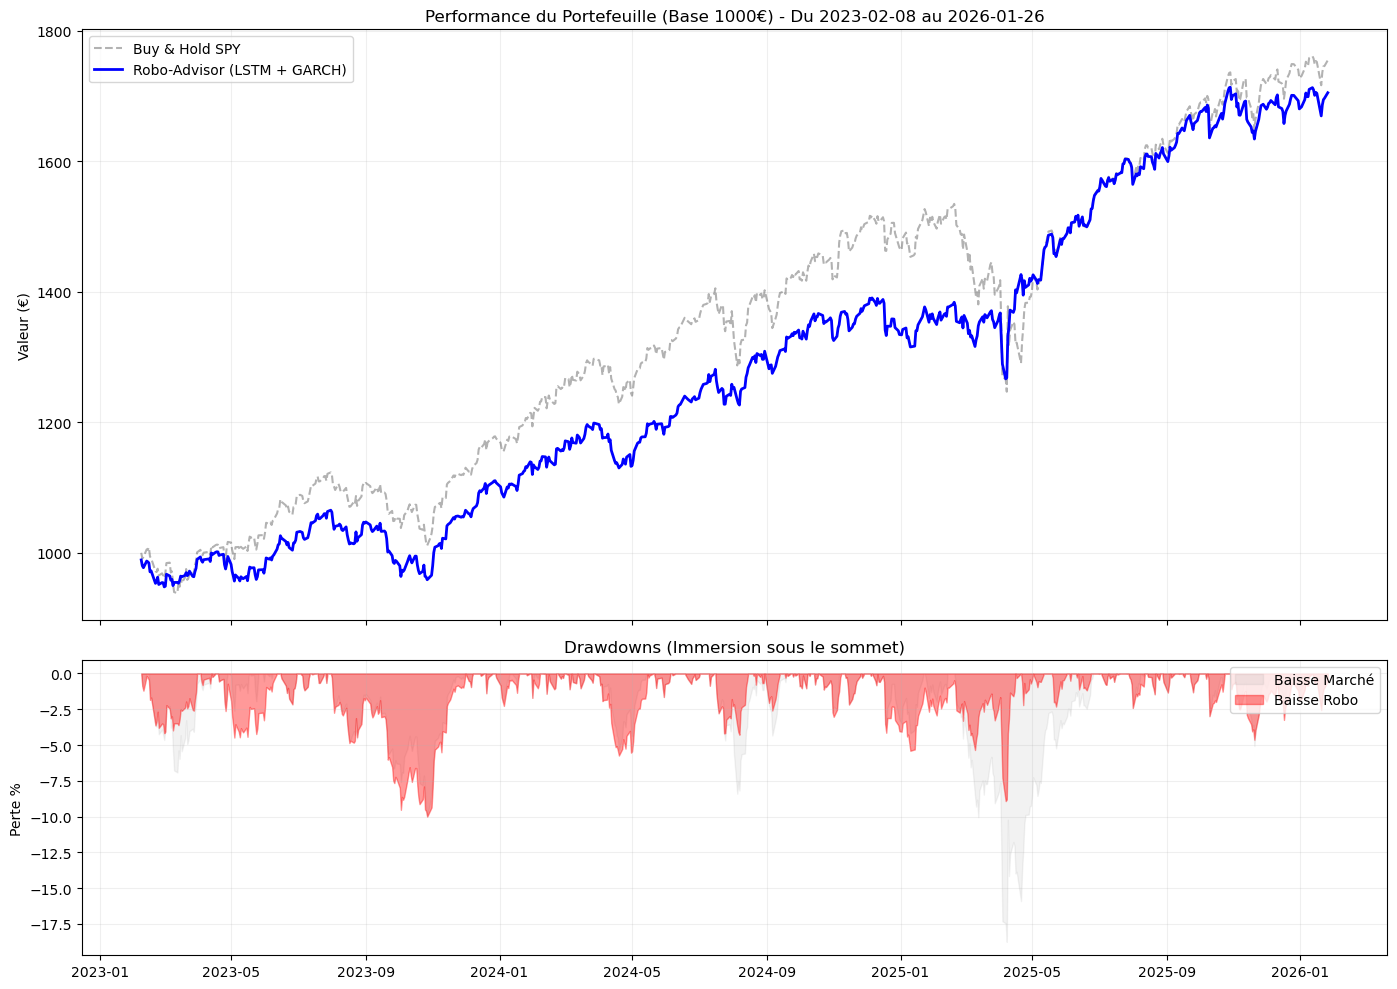

-----------------------------------------------------------------
Métrique                  | Buy & Hold      | Robo-Advisor   
-----------------------------------------------------------------
Rendement Total           |         75.49% |         70.50%
Volatilité Ann.           |         15.21% |         11.93%
Ratio de Sharpe           |           1.31 |           1.61
Max Drawdown              |        -18.76% |        -10.00%
VaR 95% (1 jour)          |         -1.42% |         -1.20%
-----------------------------------------------------------------


In [64]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Graphique de Performance
ax1.plot(df_bt['bh_wealth'], label=f"Buy & Hold SPY", color='black', alpha=0.3, ls='--')
ax1.plot(df_bt['robo_wealth'], label=f"Robo-Advisor (LSTM + GARCH)", color='blue', lw=2)
ax1.set_title(f"Performance du Portefeuille (Base 1000€) - Du {df_bt.index[0].date()} au {df_bt.index[-1].date()}")
ax1.set_ylabel("Valeur (€)")
ax1.legend()
ax1.grid(True, alpha=0.2)

# Graphique des Drawdowns
ax2.fill_between(df_bt.index, ds_bh*100, 0, color='gray', alpha=0.1, label="Baisse Marché")
ax2.fill_between(df_bt.index, ds_rb*100, 0, color='red', alpha=0.4, label="Baisse Robo")
ax2.set_ylabel("Perte %")
ax2.set_title("Drawdowns (Immersion sous le sommet)")
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("-" * 65)
print(f"{'Métrique':<25} | {'Buy & Hold':<15} | {'Robo-Advisor':<15}")
print("-" * 65)
print(f"{'Rendement Total':<25} | {p_bh:>14.2%} | {p_rb:>14.2%}")
print(f"{'Volatilité Ann.':<25} | {v_bh:>14.2%} | {v_rb:>14.2%}")
print(f"{'Ratio de Sharpe':<25} | {s_bh:>14.2f} | {s_rb:>14.2f}")
print(f"{'Max Drawdown':<25} | {d_bh:>14.2%} | {d_rb:>14.2%}")
print(f"{'VaR 95% (1 jour)':<25} | {va_bh:>14.2%} | {va_rb:>14.2%}")
print("-" * 65)

# 6. Backtest avec hysterisis et frais de transaction (0.1%)

## A. Configuration

In [65]:
initial_capital = 1000
transaction_cost = 0.001  # 0.1%
d_threshold = 0.50        # Seuil Danger
n_threshold = 0.40        # Seuil Nervosité
alloc_map = {0: [1.0, 0.0, 0.0], 1: [0.6, 0.4, 0.0], 2: [0.2, 0.0, 0.8]}

## B. Fonction d'optimisation

In [66]:
def objective(trial):
    # On suggère un buffer entre 0.01 (très réactif) et 0.30 (très filtré)
    trial_buffer = trial.suggest_float("buffer", 0.01, 0.30)
    
    current_sig = 0
    h_signals = []
    
    # Logique d'hystérésis
    for p in y_proba:
        if current_sig == 0: 
            if p[2] > (d_threshold + trial_buffer): current_sig = 2
            elif p[1] > (n_threshold + trial_buffer): current_sig = 1
        elif current_sig == 1:
            if p[2] > (d_threshold + trial_buffer): current_sig = 2
            elif p[1] < (n_threshold - trial_buffer) and p[2] < (d_threshold - trial_buffer): current_sig = 0
        elif current_sig == 2:
            if p[2] < (d_threshold - trial_buffer):
                current_sig = 1 if p[1] > n_threshold else 0
        h_signals.append(current_sig)
    
    # Simulation rapide des rendements
    temp_df = pd.DataFrame(index=test_dates)
    temp_df['signal'] = pd.Series(h_signals, index=test_dates).shift(1)
    temp_df = temp_df.join(asset_rets).dropna()
    
    cap = initial_capital
    prev_s = None
    wealth = [initial_capital]
    
    for i in range(len(temp_df)):
        s = temp_df['signal'].iloc[i]
        if prev_s is not None and s != prev_s:
            cap *= (1 - transaction_cost)
        w = alloc_map[s]
        daily_ret = (w[0]*temp_df['SPY'].iloc[i]) + (w[1]*temp_df['TLT'].iloc[i]) + (w[2]*temp_df['GLD'].iloc[i])
        cap *= (1 + daily_ret)
        wealth.append(cap)
        prev_s = s
    
    # Calcul du Max Drawdown pour le score
    wealth_ser = pd.Series(wealth)
    mdd = ((wealth_ser - wealth_ser.cummax()) / wealth_ser.cummax()).min()
    final_ret = (cap / initial_capital) - 1
    
    # Score = Rendement / Risque (On veut maximiser ce ratio)
    # On ajoute une petite constante pour éviter la division par zéro
    return final_ret / abs(mdd) if mdd != 0 else -1

## C. Execution de l'optimisation


Buffer Optimal trouvé : 0.1400


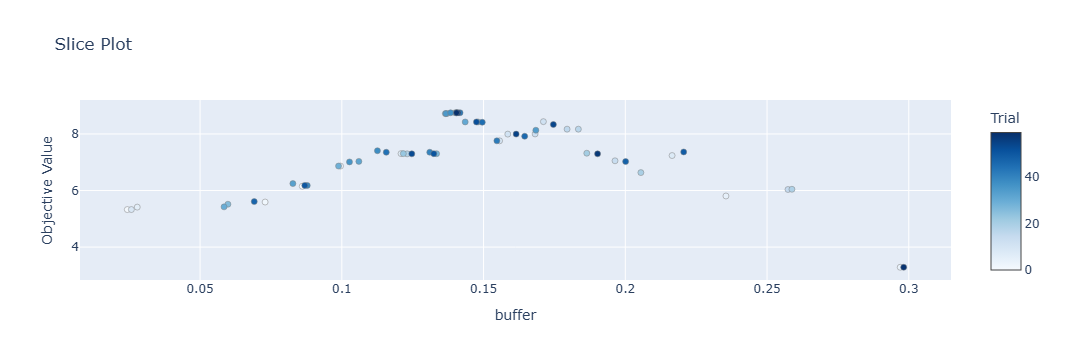

In [67]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=60)
best_buffer = study.best_params["buffer"]

print(f"\nBuffer Optimal trouvé : {best_buffer:.4f}")

# Visualisation de la stabilité du buffer
optuna.visualization.plot_slice(study, params=["buffer"]).show()

## D. Backtest final avec le buffer optimal

In [68]:
current_sig = 0
hysteresis_signals = []
for p in y_proba:
    if current_sig == 0: 
        if p[2] > (d_threshold + best_buffer): current_sig = 2
        elif p[1] > (n_threshold + best_buffer): current_sig = 1
    elif current_sig == 1:
        if p[2] > (d_threshold + best_buffer): current_sig = 2
        elif p[1] < (n_threshold - best_buffer) and p[2] < (d_threshold - best_buffer): current_sig = 0
    elif current_sig == 2:
        if p[2] < (d_threshold - best_buffer):
            current_sig = 1 if p[1] > n_threshold else 0
    hysteresis_signals.append(current_sig)

df_bt = pd.DataFrame(index=test_dates)
df_bt['signal'] = pd.Series(hysteresis_signals, index=test_dates).shift(1)
df_bt = df_bt.join(asset_rets).dropna()

current_cap = initial_capital
nb_trades = 0
prev_sig = None
robo_wealth = []

for i in range(len(df_bt)):
    sig = df_bt['signal'].iloc[i]
    if prev_sig is not None and sig != prev_sig:
        current_cap *= (1 - transaction_cost)
        nb_trades += 1
    w = alloc_map[sig]
    daily_ret = (w[0]*df_bt['SPY'].iloc[i]) + (w[1]*df_bt['TLT'].iloc[i]) + (w[2]*df_bt['GLD'].iloc[i])
    current_cap *= (1 + daily_ret)
    robo_wealth.append(current_cap)
    prev_sig = sig

df_bt['robo_wealth'] = robo_wealth
df_bt['robo_daily_ret'] = df_bt['robo_wealth'].pct_change().fillna(0)
df_bt['bh_wealth'] = (assets['Close']['SPY'].reindex(df_bt.index) / assets['Close']['SPY'].iloc[0]) * initial_capital * (1 - transaction_cost)

## E. Visualisation

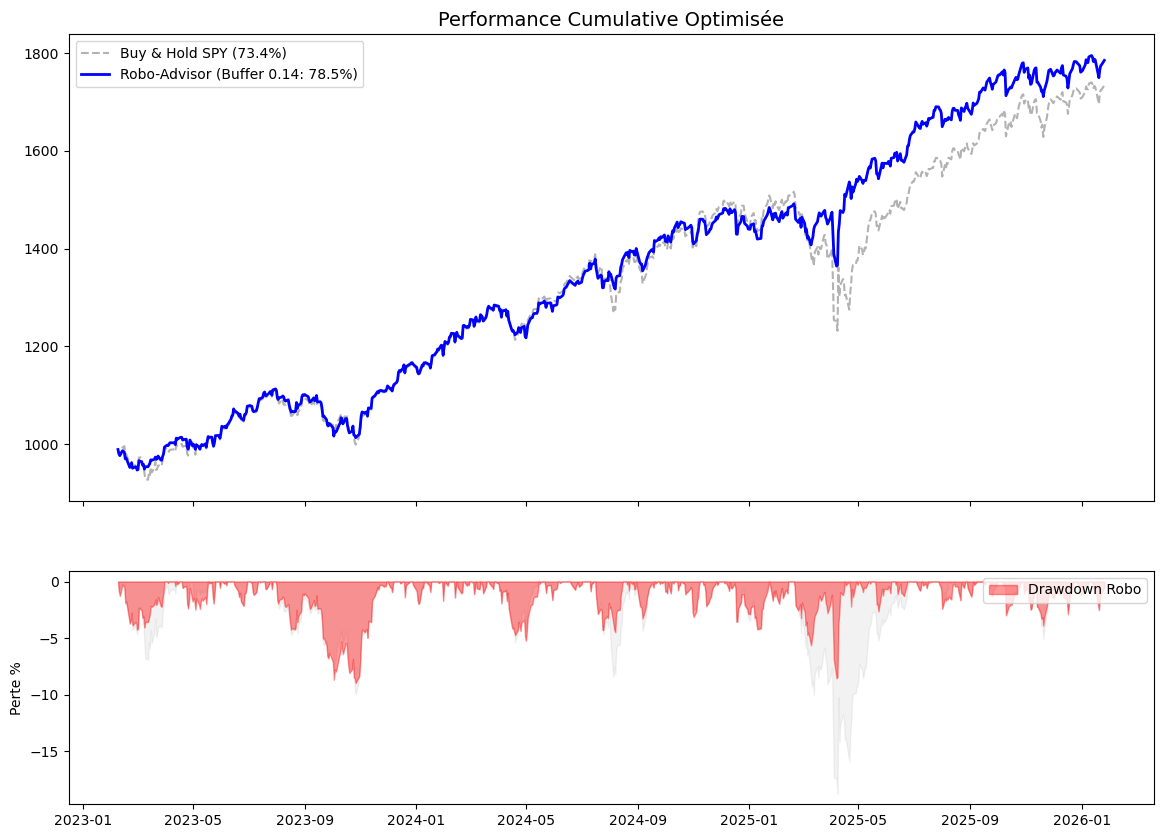

-----------------------------------------------------------------
Métrique (Net de frais)   | Buy & Hold      | Robo-Advisor   
-----------------------------------------------------------------
Nombre de Réallocations   |               1 |              37
Rendement Total           |         73.40% |         78.51%
Volatilité Annualisée     |         15.21% |         11.85%
Ratio de Sharpe           |           1.31 |           1.75
Max Drawdown              |        -18.76% |         -8.97%
VaR 95% (1 jour)          |         -1.42% |         -1.20%
-----------------------------------------------------------------


In [69]:
def analyze_performance(wealth_curve, daily_rets):
    perf = (wealth_curve.iloc[-1] / initial_capital) - 1
    vol = daily_rets.std() * np.sqrt(252)
    sharpe = (daily_rets.mean() * 252) / vol if vol != 0 else 0
    peak = wealth_curve.cummax()
    dd_series = (wealth_curve - peak) / peak
    return perf, vol, sharpe, dd_series.min(), np.percentile(daily_rets, 5), dd_series

p_bh, v_bh, s_bh, d_bh, va_bh, ds_bh = analyze_performance(df_bt['bh_wealth'], df_bt['SPY'])
p_rb, v_rb, s_rb, d_rb, va_rb, ds_rb = analyze_performance(df_bt['robo_wealth'], df_bt['robo_daily_ret'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax1.plot(df_bt['bh_wealth'], label=f"Buy & Hold SPY ({p_bh:.1%})", color='black', alpha=0.3, ls='--')
ax1.plot(df_bt['robo_wealth'], label=f"Robo-Advisor (Buffer {best_buffer:.2f}: {p_rb:.1%})", color='blue', lw=2)
ax1.set_title("Performance Cumulative Optimisée", fontsize=14)
ax1.legend()

ax2.fill_between(df_bt.index, ds_bh*100, 0, color='gray', alpha=0.1)
ax2.fill_between(df_bt.index, ds_rb*100, 0, color='red', alpha=0.4, label="Drawdown Robo")
ax2.set_ylabel("Perte %")
ax2.legend()
plt.show()

# Tableau récapitulatif
print("-" * 65)
print(f"{'Métrique (Net de frais)':<25} | {'Buy & Hold':<15} | {'Robo-Advisor':<15}")
print("-" * 65)
print(f"{'Nombre de Réallocations':<25} | {'1':>15} | {nb_trades:>15}")
print(f"{'Rendement Total':<25} | {p_bh:>14.2%} | {p_rb:>14.2%}")
print(f"{'Volatilité Annualisée':<25} | {v_bh:>14.2%} | {v_rb:>14.2%}")
print(f"{'Ratio de Sharpe':<25} | {s_bh:>14.2f} | {s_rb:>14.2f}")
print(f"{'Max Drawdown':<25} | {d_bh:>14.2%} | {d_rb:>14.2%}")
print(f"{'VaR 95% (1 jour)':<25} | {va_bh:>14.2%} | {va_rb:>14.2%}")
print("-" * 65)